# JoeyLLM Australian 5B PyTorch Training Notebook

This notebook demonstrates an initial PyTorch-based continued pretraining workflow using the 5B-token Australian dataset created for JoeyLLM.

The goal of this notebook is not to train the final production model.  
The goal is to show that the Australian 5B dataset can be connected to a language model training pipeline.

Dataset used:

```text
/home/jovyan/joeyllm_outputs/australia_5b/australia_5b_uniform_random.parquet

In [4]:

%pip install -q torch transformers pyarrow pandas tqdm accelerate

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import subprocess

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)

try:
    result = subprocess.run(
        ["nvidia-smi"],
        capture_output=True,
        text=True,
        check=False
    )
    print(result.stdout)
    print(result.stderr)
except Exception as e:
    print("Could not run nvidia-smi:", e)

PyTorch version: 2.12.0+cu130
PyTorch CUDA version: 13.0
Mon May 18 04:30:16 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.288.01             Driver Version: 535.288.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA L4                      Off | 00000000:25:00.0 Off |                    0 |
| N/A   45C    P8              17W /  72W |      0MiB / 23034MiB |      0%      Default |
|                                         |                      |                  N/A |
+----------

In [3]:
%pip uninstall -y torch torchvision torchaudio
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.12.0
Uninstalling torch-2.12.0:
  Successfully uninstalled torch-2.12.0
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 116.5 MB/s  0:00:0600:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 120.8 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 51.4 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 115.8 MB/s  0:00:000:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 143.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 79.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 117.1 MB/s  0:00:05a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 116.9 MB/s  0:00:0300:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 117.2 MB/s  0:00:0100:0100:01
     

In [1]:
import torch
import subprocess

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)

result = subprocess.run(
    ["nvidia-smi"],
    capture_output=True,
    text=True,
    check=False
)

print(result.stdout)

try:
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        print("GPU count:", torch.cuda.device_count())

        for i in range(torch.cuda.device_count()):
            print(i, torch.cuda.get_device_name(i))
    else:
        print("CUDA is not available.")

except Exception as e:
    print("CUDA check failed:")
    print(type(e).__name__, e)

PyTorch version: 2.5.1+cu121
PyTorch CUDA version: 12.1
Mon May 18 04:32:47 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.288.01             Driver Version: 535.288.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA L4                      Off | 00000000:25:00.0 Off |                    0 |
| N/A   45C    P8              17W /  72W |      0MiB / 23034MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------

In [2]:
from pathlib import Path

DATASET_PARQUET = Path("/home/jovyan/joeyllm_outputs/australia_5b/australia_5b_uniform_random.parquet")

PROJECT_DIR = Path("/home/jovyan/joeyllm_training_pytorch")
SCRIPT_PATH = PROJECT_DIR / "train_clm_ddp.py"
OUTPUT_DIR = PROJECT_DIR / "out_australia_5b_initial"
LOG_DIR = PROJECT_DIR / "logs"

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

BASE_MODEL = "gpt2"

print("Dataset parquet:", DATASET_PARQUET)
print("Dataset exists:", DATASET_PARQUET.exists())
print("Project dir:", PROJECT_DIR)
print("Training script path:", SCRIPT_PATH)
print("Output dir:", OUTPUT_DIR)
print("Log dir:", LOG_DIR)
print("Base model:", BASE_MODEL)

if not DATASET_PARQUET.exists():
    raise FileNotFoundError(f"Dataset parquet not found: {DATASET_PARQUET}")

Dataset parquet: /home/jovyan/joeyllm_outputs/australia_5b/australia_5b_uniform_random.parquet
Dataset exists: True
Project dir: /home/jovyan/joeyllm_training_pytorch
Training script path: /home/jovyan/joeyllm_training_pytorch/train_clm_ddp.py
Output dir: /home/jovyan/joeyllm_training_pytorch/out_australia_5b_initial
Log dir: /home/jovyan/joeyllm_training_pytorch/logs
Base model: gpt2


In [3]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(DATASET_PARQUET)

print("Number of row groups:", pf.num_row_groups)
print("Schema:")
print(pf.schema_arrow)

Number of row groups: 758
Schema:
text: string
id: string
dump: string
url: string
date: string
file_path: string
language: string
language_score: double
token_count: int64
index: int64
-- schema metadata --
pandas: '{"index_columns": ["index"], "column_indexes": [{"name": null, "' + 1339


In [4]:
preview_columns = ["text", "token_count"]

schema_names = pf.schema_arrow.names

if "url" in schema_names:
    preview_columns.append("url")

preview_table = pf.read_row_group(0, columns=preview_columns)
preview_df = preview_table.slice(0, 5).to_pandas()

preview_df

,text,token_count,url
0,Description - Listography: One List a Day: A T...,292,https://www.boomerangbooks.com.au/listography-...
1,“That we are legal experts is our clients’ min...,895,https://www.lawyersweekly.com.au/news/16500-un...
2,Call to request an appointment\n07 3204 9315\n...,90,https://www.dentacross.com.au/contact-us/
3,Many long-standing YWCA members will tell you ...,1193,https://www.ywca.org.au/article/five-tips-on-t...
4,"Life is just a beautiful cycle, especially whe...",618,https://www.cairnskidsactivities.com.au/useful...


In [5]:
script_code = r'''
import os
import time
import argparse
from pathlib import Path

import torch
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import IterableDataset, DataLoader

import pyarrow.parquet as pq
from transformers import AutoTokenizer, AutoModelForCausalLM, get_cosine_schedule_with_warmup


class ParquetTextIterableDataset(IterableDataset):
    def __init__(self, parquet_path, text_column, rank, world_size, max_documents=None):
        self.parquet_path = str(parquet_path)
        self.text_column = text_column
        self.rank = rank
        self.world_size = world_size
        self.max_documents = max_documents

    def __iter__(self):
        pf = pq.ParquetFile(self.parquet_path)
        seen = 0

        for row_group_idx in range(pf.num_row_groups):
            if row_group_idx % self.world_size != self.rank:
                continue

            table = pf.read_row_group(row_group_idx, columns=[self.text_column])
            texts = table[self.text_column].to_pylist()

            for text in texts:
                if text is None:
                    continue

                if not isinstance(text, str):
                    text = str(text)

                text = text.strip()

                if len(text) == 0:
                    continue

                yield text

                seen += 1

                if self.max_documents is not None and seen >= self.max_documents:
                    return


def setup_distributed():
    if "RANK" in os.environ and "WORLD_SIZE" in os.environ:
        rank = int(os.environ["RANK"])
        local_rank = int(os.environ["LOCAL_RANK"])
        world_size = int(os.environ["WORLD_SIZE"])

        torch.cuda.set_device(local_rank)
        dist.init_process_group(backend="nccl")

        distributed = True
    else:
        rank = 0
        local_rank = 0
        world_size = 1
        distributed = False

    return distributed, rank, local_rank, world_size


def cleanup_distributed(distributed):
    if distributed:
        dist.destroy_process_group()


def is_main_process(rank):
    return rank == 0


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument("--parquet_path", type=str, required=True)
    parser.add_argument("--output_dir", type=str, required=True)
    parser.add_argument("--base_model", type=str, default="gpt2")
    parser.add_argument("--text_column", type=str, default="text")

    parser.add_argument("--max_steps", type=int, default=100)
    parser.add_argument("--batch_size", type=int, default=2)
    parser.add_argument("--block_size", type=int, default=512)
    parser.add_argument("--gradient_accumulation_steps", type=int, default=4)

    parser.add_argument("--learning_rate", type=float, default=5e-5)
    parser.add_argument("--warmup_steps", type=int, default=10)
    parser.add_argument("--weight_decay", type=float, default=0.1)

    parser.add_argument("--log_interval", type=int, default=10)
    parser.add_argument("--save_interval", type=int, default=50)

    parser.add_argument("--max_documents_per_rank", type=int, default=None)

    args = parser.parse_args()

    distributed, rank, local_rank, world_size = setup_distributed()

    device = torch.device(f"cuda:{local_rank}" if torch.cuda.is_available() else "cpu")

    output_dir = Path(args.output_dir)
    if is_main_process(rank):
        output_dir.mkdir(parents=True, exist_ok=True)

    if distributed:
        dist.barrier()

    if is_main_process(rank):
        print("Starting training")
        print("Base model:", args.base_model)
        print("Parquet path:", args.parquet_path)
        print("Output dir:", args.output_dir)
        print("World size:", world_size)
        print("Batch size per GPU:", args.batch_size)
        print("Gradient accumulation:", args.gradient_accumulation_steps)
        print("Block size:", args.block_size)
        print("Max steps:", args.max_steps)

    tokenizer = AutoTokenizer.from_pretrained(args.base_model)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if torch.cuda.is_available():
        if torch.cuda.is_bf16_supported():
            model_dtype = torch.bfloat16
        else:
            model_dtype = torch.float16
    else:
        model_dtype = torch.float32

    model = AutoModelForCausalLM.from_pretrained(
        args.base_model,
        torch_dtype=model_dtype,
    )

    model.resize_token_embeddings(len(tokenizer))
    model.to(device)

    if hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()

    if distributed:
        model = DDP(model, device_ids=[local_rank], output_device=local_rank)

    dataset = ParquetTextIterableDataset(
        parquet_path=args.parquet_path,
        text_column=args.text_column,
        rank=rank,
        world_size=world_size,
        max_documents=args.max_documents_per_rank,
    )

    def collate_fn(texts):
        encoded = tokenizer(
            list(texts),
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=args.block_size,
        )

        input_ids = encoded["input_ids"]
        attention_mask = encoded["attention_mask"]

        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

    dataloader = DataLoader(
        dataset,
        batch_size=args.batch_size,
        collate_fn=collate_fn,
        num_workers=0,
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=args.learning_rate,
        weight_decay=args.weight_decay,
    )

    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=args.warmup_steps,
        num_training_steps=args.max_steps,
    )

    model.train()

    step = 0
    running_loss = 0.0
    start_time = time.time()

    optimizer.zero_grad(set_to_none=True)

    data_iter = iter(dataloader)

    while step < args.max_steps:
        accumulated_loss = 0.0

        for _ in range(args.gradient_accumulation_steps):
            try:
                batch = next(data_iter)
            except StopIteration:
                data_iter = iter(dataloader)
                batch = next(data_iter)

            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss / args.gradient_accumulation_steps

            loss.backward()

            accumulated_loss += loss.item()

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)

        step += 1
        running_loss += accumulated_loss

        if step % args.log_interval == 0:
            avg_loss = running_loss / args.log_interval
            elapsed = time.time() - start_time

            if is_main_process(rank):
                print(
                    f"step {step}: "
                    f"loss {avg_loss:.4f}, "
                    f"lr {scheduler.get_last_lr()[0]:.6e}, "
                    f"elapsed {elapsed:.1f}s",
                    flush=True,
                )

            running_loss = 0.0

        if step % args.save_interval == 0:
            if is_main_process(rank):
                save_dir = output_dir / f"checkpoint_step_{step}"

                if distributed:
                    model.module.save_pretrained(save_dir)
                else:
                    model.save_pretrained(save_dir)

                tokenizer.save_pretrained(save_dir)

                print(f"Saved checkpoint to {save_dir}", flush=True)

            if distributed:
                dist.barrier()

    if is_main_process(rank):
        final_dir = output_dir / "final_checkpoint"

        if distributed:
            model.module.save_pretrained(final_dir)
        else:
            model.save_pretrained(final_dir)

        tokenizer.save_pretrained(final_dir)

        print(f"Saved final checkpoint to {final_dir}", flush=True)

    cleanup_distributed(distributed)


if __name__ == "__main__":
    main()
'''

SCRIPT_PATH.write_text(script_code, encoding="utf-8")

print("Training script written to:")
print(SCRIPT_PATH)

Training script written to:
/home/jovyan/joeyllm_training_pytorch/train_clm_ddp.py


In [6]:
MAX_STEPS = 100
BATCH_SIZE_PER_GPU = 2
BLOCK_SIZE = 512
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 5e-5
WARMUP_STEPS = 10
SAVE_INTERVAL = 50
LOG_INTERVAL = 10

print("Initial training settings:")
print("MAX_STEPS:", MAX_STEPS)
print("BATCH_SIZE_PER_GPU:", BATCH_SIZE_PER_GPU)
print("BLOCK_SIZE:", BLOCK_SIZE)
print("GRADIENT_ACCUMULATION_STEPS:", GRADIENT_ACCUMULATION_STEPS)
print("LEARNING_RATE:", LEARNING_RATE)
print("WARMUP_STEPS:", WARMUP_STEPS)
print("SAVE_INTERVAL:", SAVE_INTERVAL)
print("LOG_INTERVAL:", LOG_INTERVAL)

Initial training settings:
MAX_STEPS: 100
BATCH_SIZE_PER_GPU: 2
BLOCK_SIZE: 512
GRADIENT_ACCUMULATION_STEPS: 4
LEARNING_RATE: 5e-05
WARMUP_STEPS: 10
SAVE_INTERVAL: 50
LOG_INTERVAL: 10


In [7]:
import torch

GPU_COUNT = torch.cuda.device_count()

if GPU_COUNT >= 2:
    launch_prefix = f"torchrun --standalone --nproc_per_node={GPU_COUNT}"
else:
    launch_prefix = "python"

train_command = (
    f"{launch_prefix} {SCRIPT_PATH} "
    f"--parquet_path {DATASET_PARQUET} "
    f"--output_dir {OUTPUT_DIR} "
    f"--base_model {BASE_MODEL} "
    f"--text_column text "
    f"--max_steps {MAX_STEPS} "
    f"--batch_size {BATCH_SIZE_PER_GPU} "
    f"--block_size {BLOCK_SIZE} "
    f"--gradient_accumulation_steps {GRADIENT_ACCUMULATION_STEPS} "
    f"--learning_rate {LEARNING_RATE} "
    f"--warmup_steps {WARMUP_STEPS} "
    f"--save_interval {SAVE_INTERVAL} "
    f"--log_interval {LOG_INTERVAL}"
)

print("GPU count:", GPU_COUNT)
print("Training command:")
print(train_command)

GPU count: 1
Training command:
python /home/jovyan/joeyllm_training_pytorch/train_clm_ddp.py --parquet_path /home/jovyan/joeyllm_outputs/australia_5b/australia_5b_uniform_random.parquet --output_dir /home/jovyan/joeyllm_training_pytorch/out_australia_5b_initial --base_model gpt2 --text_column text --max_steps 100 --batch_size 2 --block_size 512 --gradient_accumulation_steps 4 --learning_rate 5e-05 --warmup_steps 10 --save_interval 50 --log_interval 10


In [8]:
effective_global_batch_size = max(GPU_COUNT, 1) * BATCH_SIZE_PER_GPU * GRADIENT_ACCUMULATION_STEPS
tokens_per_optimizer_step = effective_global_batch_size * BLOCK_SIZE

print("GPU count:", GPU_COUNT)
print("Batch size per GPU:", BATCH_SIZE_PER_GPU)
print("Gradient accumulation steps:", GRADIENT_ACCUMULATION_STEPS)
print("Effective global batch size:", effective_global_batch_size)
print("Approx tokens per optimizer step:", tokens_per_optimizer_step)

GPU count: 1
Batch size per GPU: 2
Gradient accumulation steps: 4
Effective global batch size: 8
Approx tokens per optimizer step: 4096


In [9]:
import subprocess

LOG_PATH = LOG_DIR / "train_australia_5b_initial.log"

print("Log path:", LOG_PATH)
print("Training command:")
print(train_command)

with open(LOG_PATH, "w", encoding="utf-8") as log_f:
    process = subprocess.Popen(
        train_command,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="")
        log_f.write(line)
        log_f.flush()

    return_code = process.wait()

print("Training finished with return code:", return_code)

Log path: /home/jovyan/joeyllm_training_pytorch/logs/train_australia_5b_initial.log
Training command:
python /home/jovyan/joeyllm_training_pytorch/train_clm_ddp.py --parquet_path /home/jovyan/joeyllm_outputs/australia_5b/australia_5b_uniform_random.parquet --output_dir /home/jovyan/joeyllm_training_pytorch/out_australia_5b_initial --base_model gpt2 --text_column text --max_steps 100 --batch_size 2 --block_size 512 --gradient_accumulation_steps 4 --learning_rate 5e-05 --warmup_steps 10 --save_interval 50 --log_interval 10
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Starting training
Base model: gpt2
Parquet path: /home/jovyan/joeyllm_outputs/australia_5b/australia_5b_uniform_random.parquet
Output dir: /home/jovyan/joeyllm_training_pytorch/out_australia_5b_initial
World size: 1
Batch size per GPU: 2
Gradient accumulation: 4
Block size: 512
Max steps: 100

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 521.60it/s]
[transformers] `use_cache=True` is incompatib

In [10]:
print("Output directory:", OUTPUT_DIR)

if OUTPUT_DIR.exists():
    for p in sorted(OUTPUT_DIR.glob("*")):
        if p.is_dir():
            print("[DIR]", p)
        else:
            print("[FILE]", p, f"{p.stat().st_size / (1024 ** 2):.2f} MB")
else:
    print("Output directory does not exist.")

Output directory: /home/jovyan/joeyllm_training_pytorch/out_australia_5b_initial
[DIR] /home/jovyan/joeyllm_training_pytorch/out_australia_5b_initial/checkpoint_step_100
[DIR] /home/jovyan/joeyllm_training_pytorch/out_australia_5b_initial/checkpoint_step_50
[DIR] /home/jovyan/joeyllm_training_pytorch/out_australia_5b_initial/final_checkpoint


In [11]:
with open(LOG_PATH, "r", encoding="utf-8", errors="ignore") as f:
    lines = f.readlines()

for line in lines[-80:]:
    print(line, end="")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Starting training
Base model: gpt2
Parquet path: /home/jovyan/joeyllm_outputs/australia_5b/australia_5b_uniform_random.parquet
Output dir: /home/jovyan/joeyllm_training_pytorch/out_australia_5b_initial
World size: 1
Batch size per GPU: 2
Gradient accumulation: 4
Block size: 512
Max steps: 100

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 521.60it/s]
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
step 10: loss 3.8220, lr 5.000000e-05, elapsed 3.6s
step 20: loss 3.7045, lr 4.849232e-05, elapsed 6.5s
step 30: loss 3.7597, lr 4.415111e-05, elapsed 9.1s
step 40: loss 3.7330, lr 3.750000e-05, elapsed 11.6s
step 50: loss 3.7019, lr 2.934120e-05, elapsed 14.3s

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.20s/it]
Saved checkpoint

In [12]:
import re
import pandas as pd

records = []

pattern = re.compile(
    r"step\s+(\d+):\s+loss\s+([0-9.]+),\s+lr\s+([0-9.eE+-]+)"
)

with open(LOG_PATH, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            records.append({
                "step": int(match.group(1)),
                "loss": float(match.group(2)),
                "lr": float(match.group(3)),
            })

loss_df = pd.DataFrame(records)

print("Number of loss records:", len(loss_df))
loss_df

Number of loss records: 10


,step,loss,lr
0,10,3.8220,0.000050
1,20,3.7045,0.000048
2,30,3.7597,0.000044
3,40,3.7330,0.000037
4,50,3.7019,0.000029
5,60,3.6330,0.000021
6,70,3.6866,0.000013
7,80,3.7489,0.000006
8,90,3.6177,0.000002
9,100,3.7461,0.000000


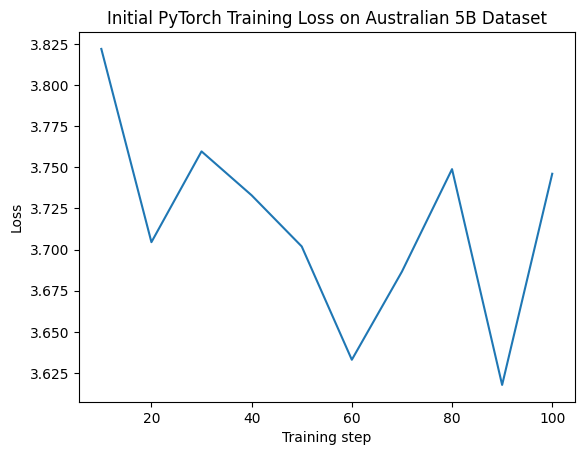

In [13]:
import matplotlib.pyplot as plt

if len(loss_df) > 0:
    plt.figure()
    plt.plot(loss_df["step"], loss_df["loss"])
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.title("Initial PyTorch Training Loss on Australian 5B Dataset")
    plt.show()
else:
    print("No loss records found.")